In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor # For regression task
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('Iris.csv')

In [3]:
data.head()

,Unnamed: 0,sepal_length,sepal_width,petal_length,petal_width,target
0,0,5.1,3.5,1.4,0.2,0
1,1,4.9,3.0,1.4,0.2,0
2,2,4.7,3.2,1.3,0.2,0
3,3,4.6,3.1,1.5,0.2,0
4,4,5.0,3.6,1.4,0.2,0


In [4]:

df=data[['sepal_length', 'sepal_width', 'petal_length','petal_width']]

In [5]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [6]:
df

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
data.target.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

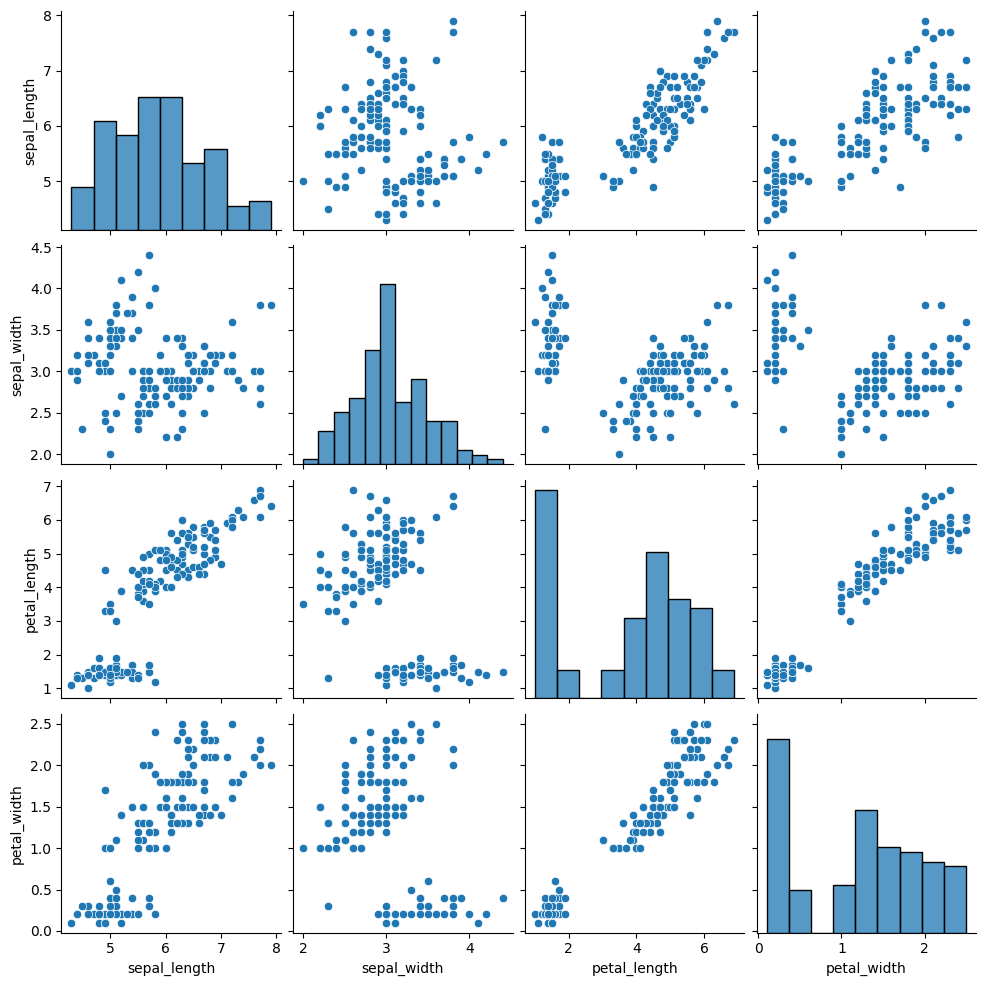

In [8]:
sns.pairplot(df)

In [9]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
dtype: int64

In [10]:
X= data.iloc[:,:-1]
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=6, random_state=42)
model.fit(X)

KMeans(n_clusters=6, random_state=42)

In [12]:
X.shape

(150, 4)

In [13]:
model.cluster_centers_

array([[6.20769231, 2.85384615, 4.74615385, 1.56410256],
       [4.81818182, 3.22121212, 1.43636364, 0.22727273],
       [5.508     , 2.6       , 3.908     , 1.204     ],
       [7.475     , 3.125     , 6.3       , 2.05      ],
       [6.52916667, 3.05833333, 5.50833333, 2.1625    ],
       [5.37058824, 3.8       , 1.51764706, 0.27647059]])

In [14]:
color_scheme = np.array(['red','blue','green','yellow','pink','cyan','black'])

In [15]:
color_scheme

array(['red', 'blue', 'green', 'yellow', 'pink', 'cyan', 'black'],
      dtype='<U6')

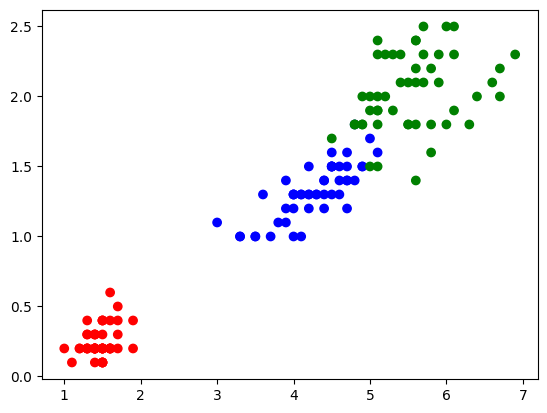

In [16]:
plt.scatter(data.petal_length,data.petal_width,color=color_scheme[data.target])

In [17]:
model.labels_

array([1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 5, 1, 1, 1, 5, 5, 5, 1, 5, 5, 5, 5,
       1, 1, 1, 1, 1, 5, 1, 1, 1, 5, 5, 5, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1,
       5, 1, 5, 1, 5, 1, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0,
       0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 4, 0, 3, 4, 4, 3, 2, 3, 4, 3,
       4, 4, 4, 0, 4, 4, 4, 3, 3, 0, 4, 0, 3, 0, 4, 3, 0, 0, 4, 3, 3, 3,
       4, 0, 0, 3, 4, 4, 0, 4, 4, 4, 0, 4, 4, 4, 0, 4, 4, 0])

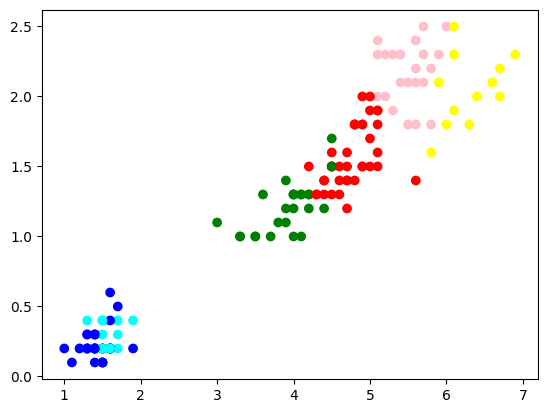

In [18]:
plt.scatter(X.petal_length,X.petal_width,color=color_scheme[model.labels_]);

In [19]:
X['Group']= pd.DataFrame(model.labels_)
X.head(10)

,sepal_length,sepal_width,petal_length,petal_width,Group
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1
5,5.4,3.9,1.7,0.4,5
6,4.6,3.4,1.4,0.3,1
7,5.0,3.4,1.5,0.2,1
8,4.4,2.9,1.4,0.2,1
9,4.9,3.1,1.5,0.1,1


In [20]:
new_point=[[6.4,5.6,5.4,0.8]] # A new observation where it will go 
#means which cluster
model.predict(new_point)

array([4])

In [21]:
type(new_point)

list

In [22]:
#elbow method
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

In [23]:
for i in range(1,11):
    print(i,wcss[i-1])

1 1130.8244
2 699.4058393308694
3 327.9784080298786
4 231.91686646686645
5 59.55933089263678
6 55.965232479938365
7 35.65773247993836
8 31.451700428656313
9 29.75670042865631
10 27.243060277141158


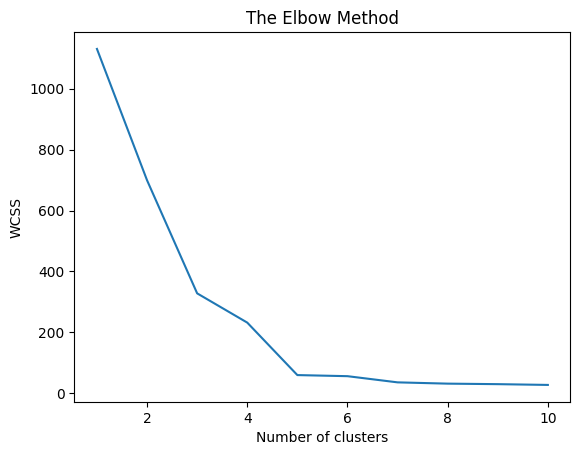

In [24]:
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [25]:
wcss
for i in range(10):
    print(i+1,"  ",wcss[i])

1    1130.8244
2    699.4058393308694
3    327.9784080298786
4    231.91686646686645
5    59.55933089263678
6    55.965232479938365
7    35.65773247993836
8    31.451700428656313
9    29.75670042865631
10    27.243060277141158


In [26]:
label=model.labels_
label

from sklearn.metrics import silhouette_score
score=silhouette_score(X,label)
score #k=3

0.7119901474053052